1.LOAD DATASET

In [15]:
import pandas as pd

PLATFORM = "TikTok"

train_df = pd.read_csv(
    "../data_preprocess/processed_data/ml_data/tiktok_train.csv"
)

test_df = pd.read_csv(
    "../data_preprocess/processed_data/ml_data/tiktok_test.csv"
)

print(train_df.shape)
print(test_df.shape)

(9509, 57)
(2378, 57)


In [17]:
# --- CODE XEM GIÁ TRỊ POPULARITY TẠI ĐÂY ---
print("\n" + "="*30)
print("PHÂN BỔ LỚP TRONG TẬP TRAIN")
print("="*30)
print(train_df["popularity"].value_counts())
print("\nTỷ lệ %:")
print(train_df["popularity"].value_counts(normalize=True) * 100)

print("\n" + "="*30)
print("PHÂN BỔ LỚP TRONG TẬP TEST")
print("="*30)
print(test_df["popularity"].value_counts())
print("\nTỷ lệ %:")
print(test_df["popularity"].value_counts(normalize=True) * 100)


PHÂN BỔ LỚP TRONG TẬP TRAIN
popularity
0    7607
1    1902
Name: count, dtype: int64

Tỷ lệ %:
popularity
0    79.997897
1    20.002103
Name: proportion, dtype: float64

PHÂN BỔ LỚP TRONG TẬP TEST
popularity
0    1902
1     476
Name: count, dtype: int64

Tỷ lệ %:
popularity
0    79.983179
1    20.016821
Name: proportion, dtype: float64


In [19]:
X_train = train_df.drop(
    columns=[
        "post_id",
        "user_id",
        "popularity"
    ]
)
y_train = train_df["popularity"]

X_test = test_df.drop(
    columns=[
        "post_id",
        "user_id",
        "popularity"
    ]
)
y_test = test_df["popularity"]

In [ ]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Calculate class imbalance ratio
ratio = 7607 / 1902  

# Initialize XGBoost with optimized parameters
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=ratio,     # Handle imbalanced data
    n_estimators=500,           # Number of boosting rounds
    learning_rate=0.02,         # Step size shrinkage
    max_depth=6,                # Maximum tree depth
    min_child_weight=1,         # Minimum sum of instance weight
    gamma=0.1,                  # Minimum loss reduction
    subsample=0.8,              # Fraction of training data per tree
    colsample_bytree=0.8,       # Fraction of features per tree
    random_state=42,            # For reproducibility
    n_jobs=-1                   # Use all CPU cores
)

In [21]:
print("\n" + "=" * 60)
print("TRAINING XGBOOST...")
print("=" * 60)

model.fit(
    X_train,
    y_train
)


TRAINING XGBOOST...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [22]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# Get probability scores for the positive class
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate precision-recall pairs
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Calculate F1-score for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

# Locate the threshold that yields the highest F1-score
best_threshold = thresholds[np.argmax(f1_scores)]

# Apply the optimal threshold to generate final predictions
y_pred = (y_prob >= best_threshold).astype(int)

In [23]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [24]:
# CLASSIFICATION REPORT
# =====================================================
from sklearn.metrics import classification_report

print("\n" + "=" * 60)
print("HYBRID MODEL CLASSIFICATION REPORT (METADATA)")
print("=" * 60)

# Thêm tham số digits=4 vào đây
report = classification_report(
    y_test, 
    y_pred, 
    digits=4
)

print(report)

# Đảm bảo ROC-AUC cũng đồng bộ 4 chữ số
print(f"ROC-AUC SCORE : {roc_auc:.4f}")
print("=" * 60)


HYBRID MODEL CLASSIFICATION REPORT (METADATA)
              precision    recall  f1-score   support

           0     0.9176    0.8607    0.8882      1902
           1     0.5539    0.6912    0.6150       476

    accuracy                         0.8267      2378
   macro avg     0.7357    0.7759    0.7516      2378
weighted avg     0.8448    0.8267    0.8335      2378

ROC-AUC SCORE : 0.8693


In [25]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


CONFUSION MATRIX
[[1637  265]
 [ 147  329]]


In [26]:
importance_df = pd.DataFrame({

    "feature": X_train.columns,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP 15 IMPORTANT FEATURES")
print("=" * 60)

print(
    importance_df.head(15)
)


TOP 15 IMPORTANT FEATURES
                feature  importance
15        followers_log    0.135822
3             followers    0.115266
5              verified    0.092352
44      media_type_Link    0.016686
23      topic_Education    0.015793
27           topic_Food    0.015778
39       language_Hindi    0.015336
26        topic_Finance    0.015239
4      account_age_days    0.014890
19  sentiment_intensity    0.014791
9    sentiment_negative    0.014677
47     media_type_Video    0.014394
32         topic_Sports    0.014321
25        topic_Fashion    0.013975
11             hour_sin    0.013960


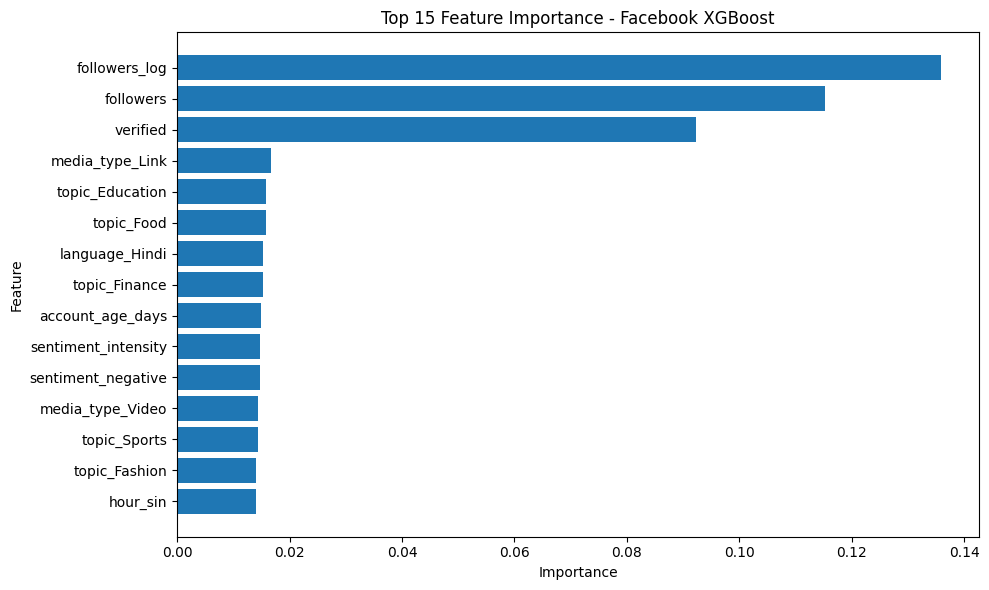

In [27]:
import matplotlib.pyplot as plt
top_n = 15

plot_df = importance_df.head(top_n)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 Feature Importance - Facebook XGBoost"
)

plt.tight_layout()

plt.show()